In [1]:
import pandas as pd
import numpy as np
from fredapi import Fred
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:
fred = Fred(api_key='1652ffd9db8627b52124e92ecbb6895b')
raw_gdp = fred.get_series("A191RL1Q225SBEA", observation_start="1947-01-01", observation_end="2019-12-31")

In [3]:
df = pd.DataFrame(raw_gdp, columns=['gdp'])
df.index.name = 'date'
df.index.freq = 'QS'

In [4]:
p, d, q = 2, 1, 0 
model = ARIMA(df['gdp'], order=(p, d, q))

In [5]:
model_fit = model.fit()


# Specify model order: AR(2) with 1st-order differencing, no MA component
p, d, q = 2, 1, 0

# Set the backtest evaluation range
start_backtest = "2005-01-01"
end_backtest = "2019-12-31"

# Identify the pandas index locations for our backtest timeline
backtest_dates = df.loc[start_backtest:end_backtest].index

history = df.loc[:start_backtest].iloc[:-1]  # Initial history up to end of 2004
predictions = []
actuals = []

In [6]:
# ==========================================
# 3. WALK-FORWARD BACKTEST LOOP
# ==========================================
print("Running backtest loop...")
for target_date in backtest_dates:
    # Actual value we want to predict
    actual_val = df.loc[target_date, "gdp"]
    actuals.append(actual_val)

    # Convert history target series and force frequency to avoid statsmodels warnings
    train_series = history["gdp"].asfreq("QS")

    # Fit ARIMA model on the expanded history
    model = ARIMA(train_series, order=(p, d, q))
    model_fit = model.fit()

    # Forecast exactly 1 step ahead (the target_date quarter)
    pred_val = model_fit.forecast(steps=1).iloc[0]
    predictions.append(pred_val)

    # Update history by appending the true observed value for the next iteration
    new_row = pd.DataFrame([[actual_val]], columns=["gdp"], index=[target_date])
    history = pd.concat([history, new_row])

Running backtest loop...


In [15]:
# ==========================================
# 4. EVALUATE RESULTS
# ==========================================
results_df = pd.DataFrame({"Actual": actuals, "Predicted": predictions}, index=backtest_dates)

# Calculate Evaluation Metrics
rmse = np.sqrt(mean_squared_error(results_df["Actual"], results_df["Predicted"]))
mae = np.mean(np.abs(results_df["Actual"] - results_df["Predicted"]))

print(f"\n--- Backtest Metrics (2005-2019) ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}pp")
print(f"Mean Absolute Error (MAE): {mae:.2f}pp")

# View the final head of your backtest comparisons
print("\nFirst few backtest comparisons:")
print(results_df.head())


--- Backtest Metrics (2005-2019) ---
Root Mean Squared Error (RMSE): 2.36pp
Mean Absolute Error (MAE): 1.81pp

First few backtest comparisons:
            Actual  Predicted
date                         
2005-01-01     4.5   3.902131
2005-04-01     2.0   4.296753
2005-07-01     3.2   3.053790
2005-10-01     2.2   2.914990
2006-01-01     5.5   2.522502


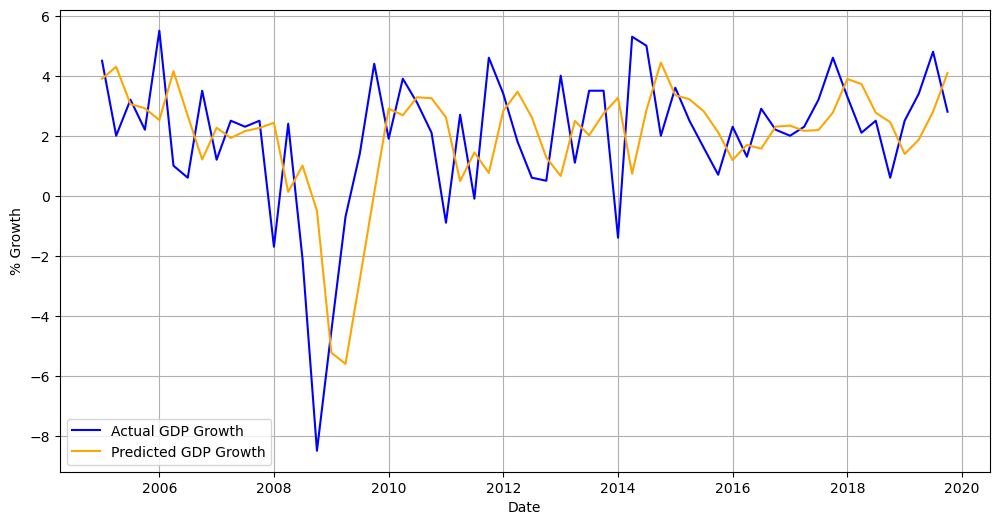

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(results_df['Actual'], label='Actual GDP Growth', color='blue')
plt.plot(results_df['Predicted'], label='Predicted GDP Growth', color='orange')
plt.ylabel("% Growth")
plt.xlabel("Date")
plt.legend()
plt.grid()